FUNCTIONAL LOOKUP TABLE — C. elegans

CANONICAL NOMENCLATURE: Sulston 1983 notation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
cells_birth_and_pos.csv and ce_temporal_data.csv both use Sulston notation
natively (e.g. ABplapaaaapp, MSaapa, Cpapa). Using the same convention
throughout the project means zero-translation lookups at every step.

WormBase (Alignment_map.xlsx) uses a slightly different format:
  - Inserts a space after the root:      "AB plapaaaapp"
  - Uses dots for P-lineage cells:       "P1.apa"
  - Appends terminal orientation suffix: "AB alpppapav" (v = ventral)

THREE NORMALIZATION RULES APPLIED:
  Rule 1  Remove all spaces        "AB plapaaaapp" → "ABplapaaaapp"
  Rule 2  Remove dots (AB/MS/P..)  "P1.apa"        → "P1apa"
  Rule 3  Strip suffix v or d      "AB alpppapav"  → "ABalpppapa"

Loading data files...
  Alignment_mapcsv.csv  : 1359 rows, 694 unique cells
  Connectome.csv      : 2279 rows, 271 source neurons

  Added 5 missing neurons: ['AVFL', 'AVFR', 'DB1',

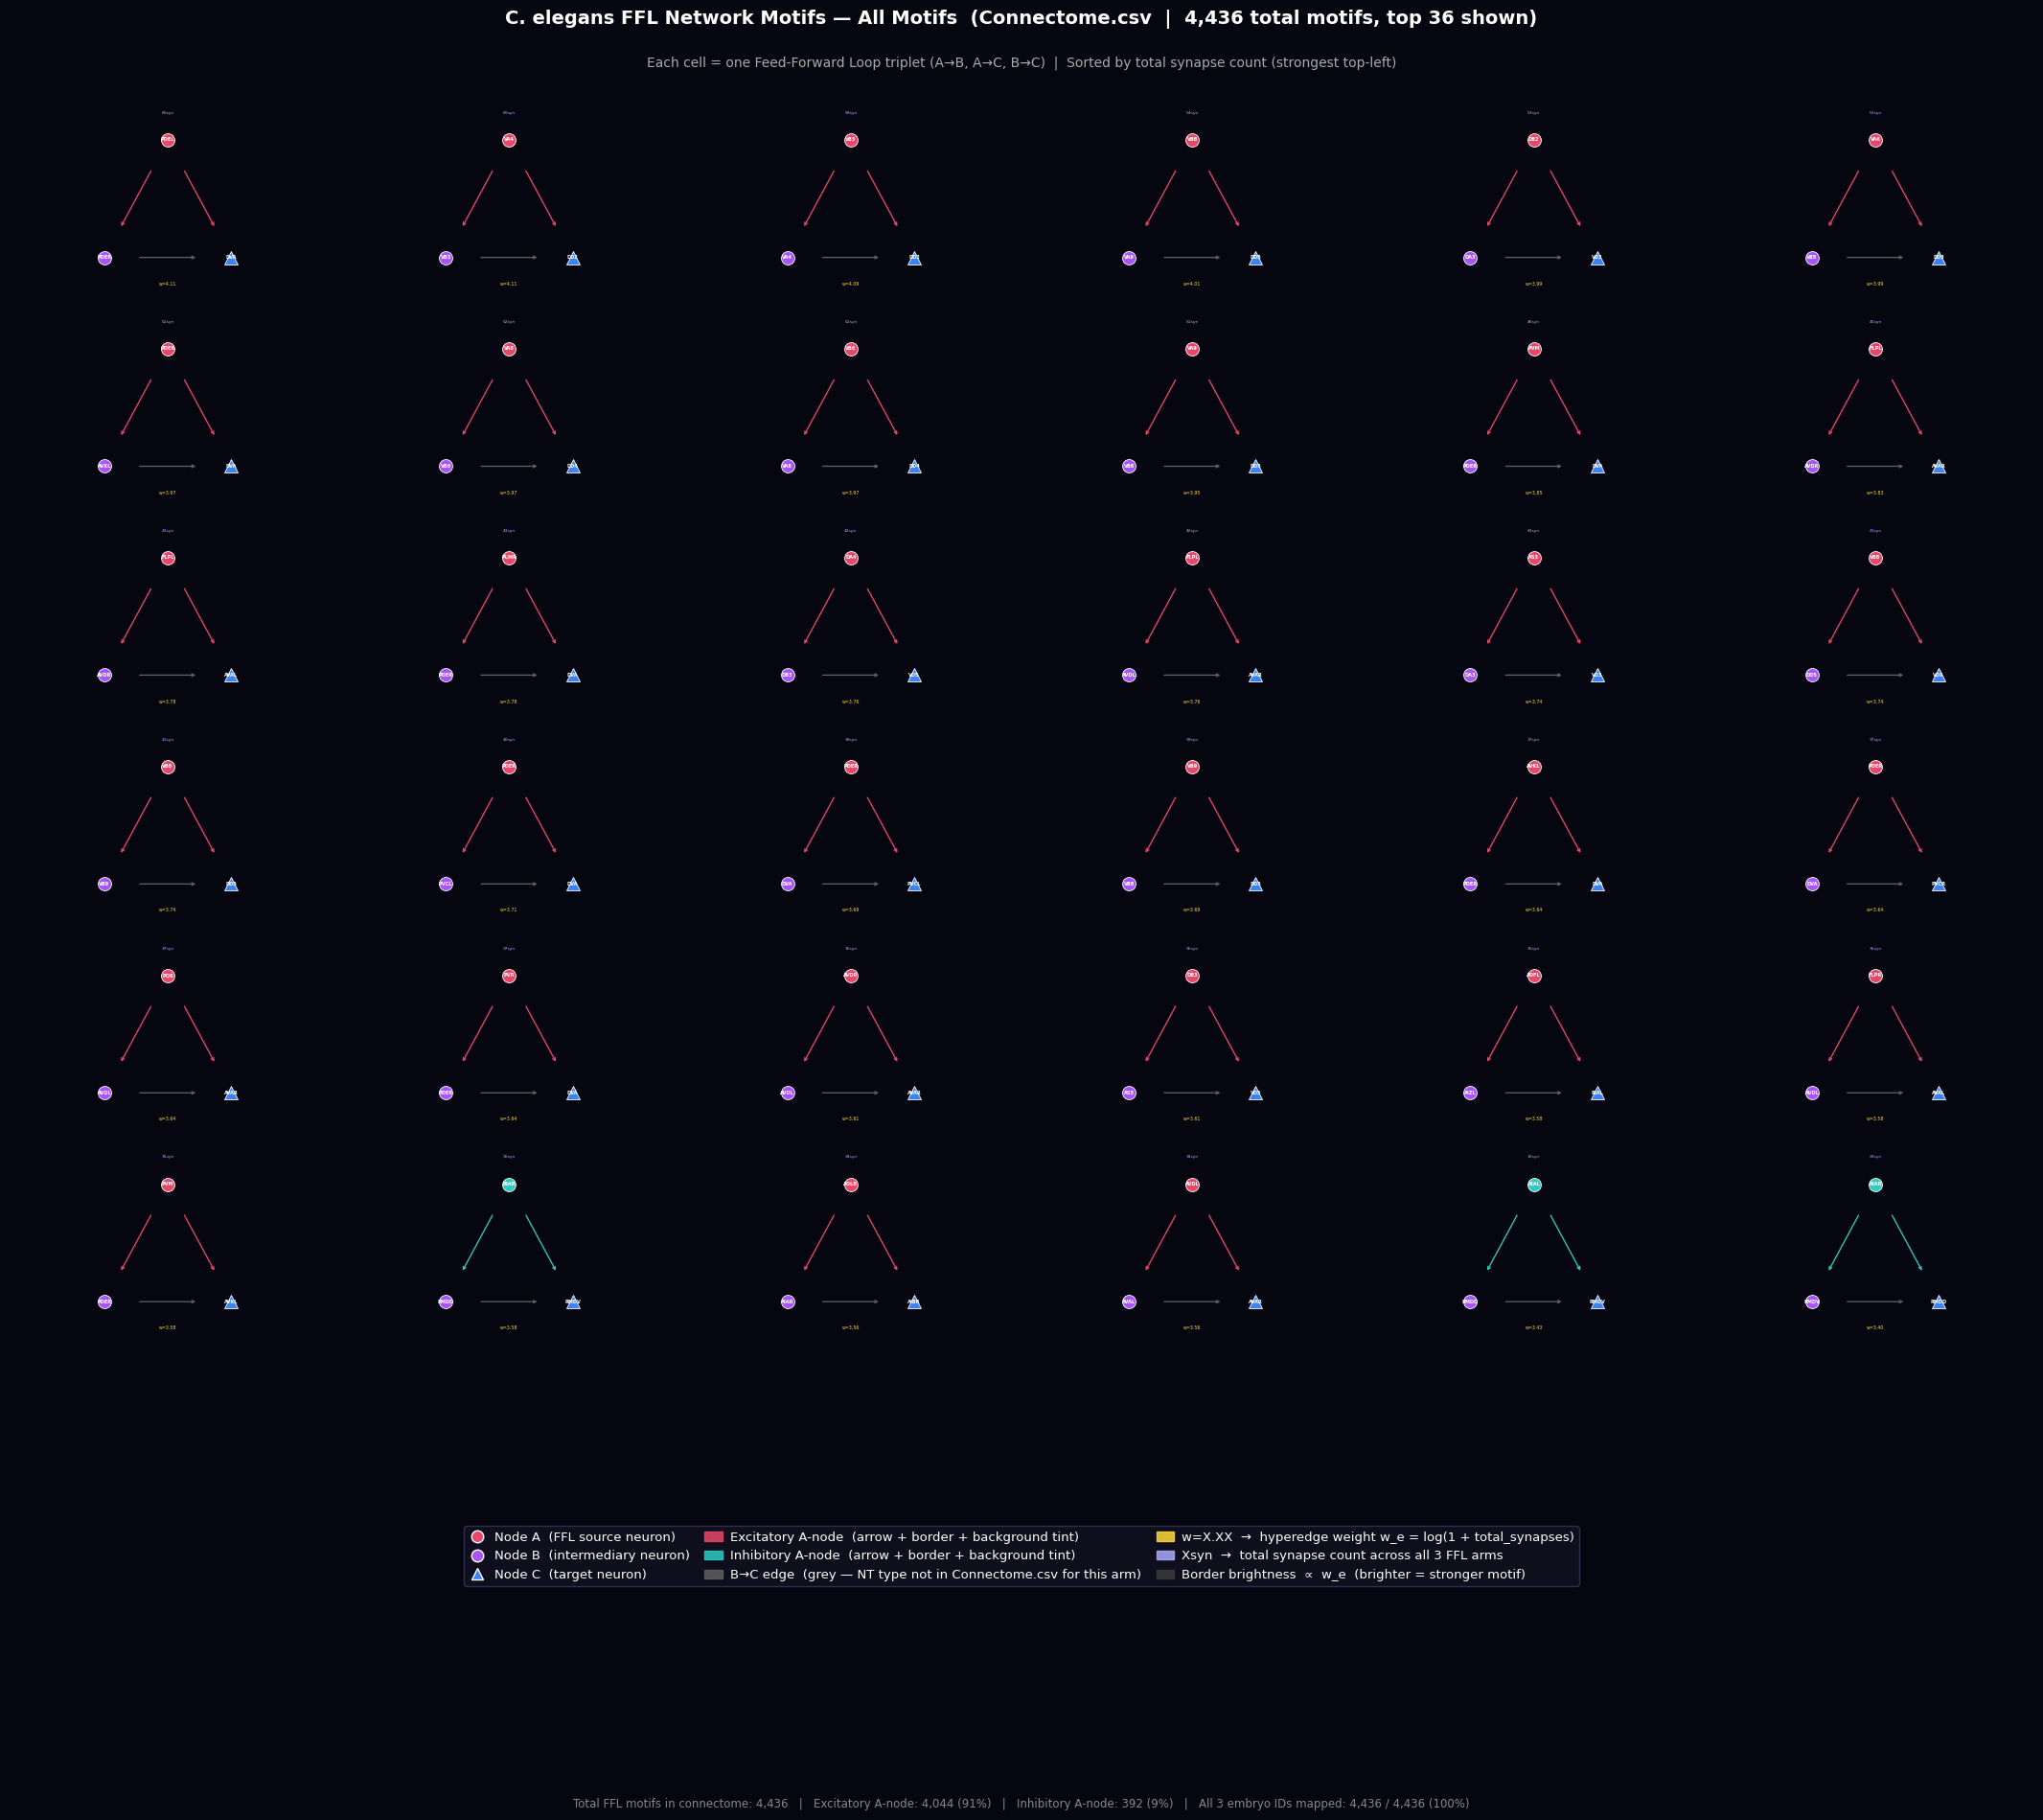


  Figure saved → output_tables\ffl_motif_grid.png

  HOW TO READ THIS FIGURE:
  ─────────────────────────────────────────────────────────────────
  • Each cell in the grid = one FFL motif from your connectome data
  • Reading left→right, top→bottom: strongest → weakest motifs
  • Pink/red cells   = excitatory A-node (91% of all FFLs)
  • Teal/cyan cells  = inhibitory A-node (9% of all FFLs)
  • Top number (blue)= total synapses across all 3 arms of triangle
  • Bottom number (gold) = w_e = log(1 + synapses) = incidence matrix value
  • Border brightness = relative motif strength (brightest = strongest)
  • In H_functional: each cell in this grid becomes ONE COLUMN of the
    incidence matrix. The 3 embryo Sulston names in that motif are the
    3 ROWS that receive a non-zero entry in that column.


In [8]:
%run build_functional_lookup_table_with_viz.py

In [9]:
%run build_anastomosis_final_2.py

ANASTOMOSIS TABLE — FINAL VERSION (phantom-free · 11 columns)

Step 1: Loading ce_temporal_data.csv...
  Shape          : (250113, 7)
  Unique cells   : 780
  Timepoints     : t=1 to t=190

  NOTE: each cell name appears multiple times per timepoint
  (multiple embryos tracked simultaneously). drop_duplicates
  keeps the first occurrence, which is consistent for established
  cells but can jump for newly-born cells. XYZ is excluded from
  the table for this reason; cluster membership is still correct.

Step 2: Detecting genuine anastomosis events...
  Phantom filter: skip if set(old_members) == set(new_members)
  Raw detected events    : 14678
  Phantom events removed : 2939  <- saved to phantom_events_table.csv
  Genuine events kept    : 11739
  Unique switching cells : 689
  t_switch range         : t=53 to t=189

Phantom table preview (first 5 rows):
  phantom_id      cell  t_switch  cluster_size                 members  old_label_int  new_label_int                         why_phant